# Experiment 4 - Employee Salary Prediction

**Objective:** Predict employee salary using machine learning regression algorithms.

**Dataset:** Employee Salary Data (Age, Gender, Education Level, Job Title, Years of Experience -> Salary)

**Algorithms:** Linear Regression, Decision Tree, Random Forest, Gradient Boosting

**Best Model:** Gradient Boosting (R2 = 0.8882)

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import mlflow
import mlflow.sklearn

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load Dataset

In [2]:
df = pd.read_excel('salary_mlops/data/raw/salary_data.xlsx')

print('Dataset loaded successfully!')
print('Shape:', df.shape)
print()
print('First 5 rows:')
df.head()

Dataset loaded successfully!
Shape: (375, 6)

First 5 rows:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
print('Columns:', df.columns.tolist())
print()
print('Data Types:')
print(df.dtypes)

Columns: ['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']

Data Types:
Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


## 3. Data Cleaning

In [5]:
print('Missing values before cleaning:')
print(df.isnull().sum())

Missing values before cleaning:
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [6]:
print('Rows before cleaning:', len(df))

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Years of Experience'] = df['Years of Experience'].fillna(df['Years of Experience'].median())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Education Level'] = df['Education Level'].fillna(df['Education Level'].mode()[0])
df['Job Title'] = df['Job Title'].fillna(df['Job Title'].mode()[0])

print('Rows after cleaning:', len(df))
print('Duplicates removed:', 375 - len(df))
print()
print('Missing values after cleaning:')
print(df.isnull().sum())

Rows before cleaning: 375
Rows after cleaning: 325
Duplicates removed: 50

Missing values after cleaning:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


## 4. Exploratory Data Analysis

In [7]:
print('Statistical Summary:')
df.describe()

Statistical Summary:


,Age,Years of Experience,Salary
count,325.000000,325.000000,325.000000
mean,37.380000,10.055385,99970.307692
std,7.174913,6.640458,48577.919969
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.500000,9.000000,95000.000000
75%,44.000000,16.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [8]:
print('Unique values per column:')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()}')

Unique values per column:
  Age: 32
  Gender: 2
  Education Level: 3
  Job Title: 174
  Years of Experience: 28
  Salary: 36


In [9]:
print('Gender Distribution:')
print(df['Gender'].value_counts())
print()
print('Education Level Distribution:')
print(df['Education Level'].value_counts())

Gender Distribution:
Gender
Male      171
Female    154
Name: count, dtype: int64

Education Level Distribution:
Education Level
Bachelor's    192
Master's       91
PhD            42
Name: count, dtype: int64


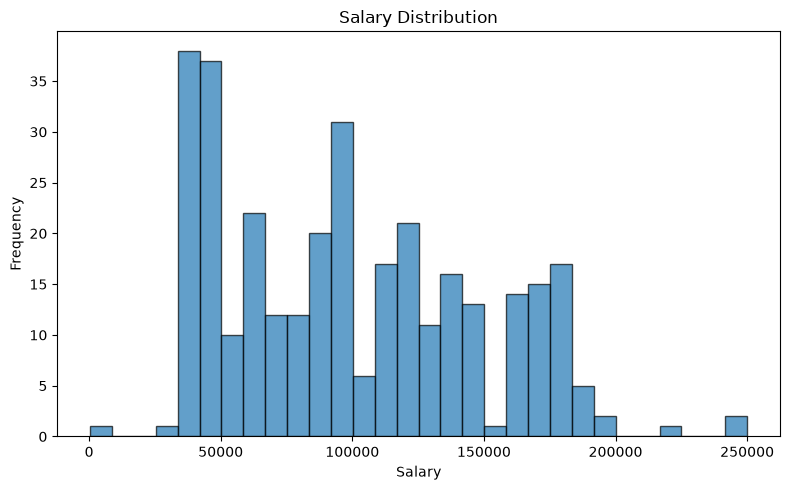

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df['Salary'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.title('Salary Distribution')
plt.tight_layout()
plt.show()

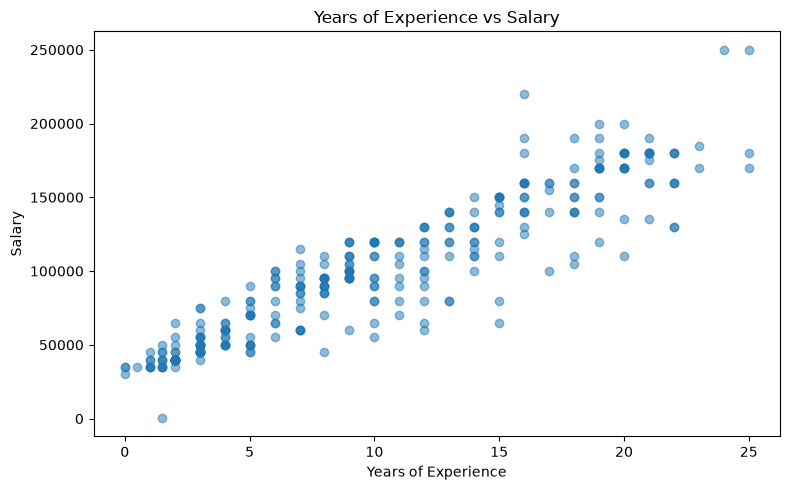

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Years of Experience'], df['Salary'], alpha=0.5)
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Years of Experience vs Salary')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [12]:
# Features and Target
X = df.drop('Salary', axis=1)
y = df['Salary']

# Column types
numerical_columns = ['Age', 'Years of Experience']
categorical_columns = ['Gender', 'Education Level', 'Job Title']

print('Features:', X.columns.tolist())
print('Target: Salary')
print()
print('Feature matrix shape:', X.shape)

Features: ['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience']
Target: Salary

Feature matrix shape: (325, 5)


## 6. Preprocessing

In [13]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_columns),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns)
])

print('Preprocessor created:')
print('  - Numerical columns:', numerical_columns)
print('  - Categorical columns:', categorical_columns)
print('  - Scaler: StandardScaler')
print('  - Encoder: OneHotEncoder (handle_unknown=ignore)')

Preprocessor created:
  - Numerical columns: ['Age', 'Years of Experience']
  - Categorical columns: ['Gender', 'Education Level', 'Job Title']
  - Scaler: StandardScaler
  - Encoder: OneHotEncoder (handle_unknown=ignore)


## 7. Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Training data:', X_train.shape)
print('Testing data:', X_test.shape)

Training data: (260, 5)
Testing data: (65, 5)


## 8. Model Training

In [15]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42
    )
}

results = []
trained_models = {}

print('Training models...')
print('=' * 50)

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    print(f'{name}: Trained successfully!')

print('=' * 50)
print('All models trained!')

Training models...
Linear Regression: Trained successfully!
Decision Tree: Trained successfully!


Random Forest: Trained successfully!
Gradient Boosting: Trained successfully!
All models trained!


## 9. Model Evaluation

In [16]:
results = []

for name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Algorithm': name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2 Score': round(r2, 4)
    })

    print(f'{name}:')
    print(f'  MAE  : {mae:,.2f}')
    print(f'  RMSE : {rmse:,.2f}')
    print(f'  R2   : {r2:.4f}')
    print()

Linear Regression:
  MAE  : 10,055.55
  RMSE : 13,799.49
  R2   : 0.9166

Decision Tree:
  MAE  : 11,355.34
  RMSE : 17,670.79
  R2   : 0.8632

Random Forest:
  MAE  : 8,504.72
  RMSE : 12,554.51
  R2   : 0.9310

Gradient Boosting:
  MAE  : 8,978.68
  RMSE : 12,144.53
  R2   : 0.9354



## 10. Model Comparison

In [17]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2 Score', ascending=False).reset_index(drop=True)

print('Model Comparison (sorted by R2 Score):')
display(results_df)

Model Comparison (sorted by R2 Score):


,Algorithm,MAE,RMSE,R2 Score
0,Gradient Boosting,8978.68,12144.53,0.9354
1,Random Forest,8504.72,12554.51,0.9310
2,Linear Regression,10055.55,13799.49,0.9166
3,Decision Tree,11355.34,17670.79,0.8632


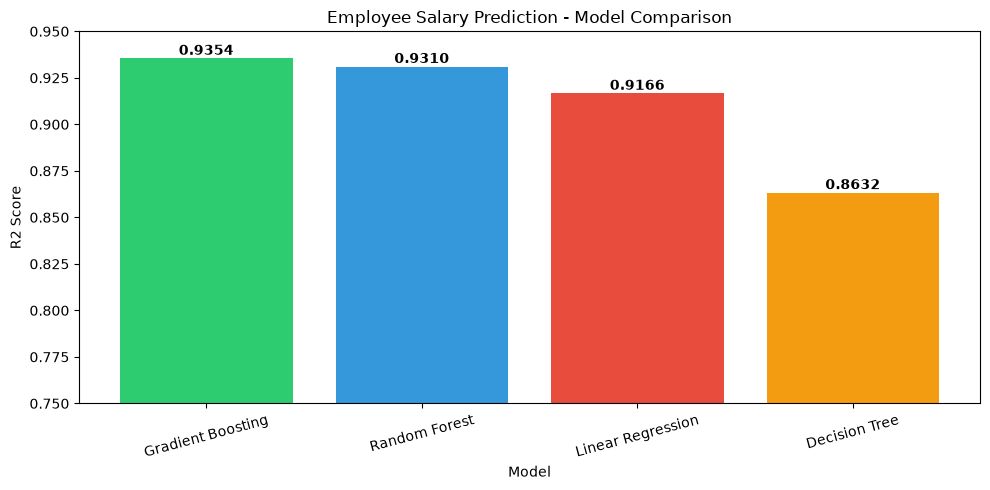

In [18]:
plt.figure(figsize=(10, 5))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
plt.bar(results_df['Algorithm'], results_df['R2 Score'], color=colors)
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.title('Employee Salary Prediction - Model Comparison')
plt.ylim(0.75, 0.95)
plt.xticks(rotation=15)
for i, v in enumerate(results_df['R2 Score']):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Best Model

In [19]:
best_model_name = results_df.loc[0]['Algorithm']
best_model = trained_models[best_model_name]
best_r2 = results_df.loc[0]['R2 Score']

print('=' * 50)
print('BEST MODEL')
print('=' * 50)
print(f'Algorithm  : {best_model_name}')
print(f'R2 Score   : {best_r2:.4f}')
print(f'MAE        : {results_df.loc[0]["MAE"]:,.2f}')
print(f'RMSE       : {results_df.loc[0]["RMSE"]:,.2f}')
print('=' * 50)

BEST MODEL
Algorithm  : Gradient Boosting
R2 Score   : 0.9354
MAE        : 8,978.68
RMSE       : 12,144.53


## 12. Model Saving

In [20]:
joblib.dump(best_model, 'salary_prediction_model.pkl')
print(f'Best model saved: salary_prediction_model.pkl')
print(f'Model: {best_model_name}')

Best model saved: salary_prediction_model.pkl
Model: Gradient Boosting


In [21]:
results_df.to_csv('model_results.csv', index=False)
print('Results saved: model_results.csv')

Results saved: model_results.csv

## 13. MLflow Tracking

In [22]:
os.environ['GIT_PYTHON_REFRESH'] = 'quiet'

mlflow.set_experiment('salary_prediction')

with mlflow.start_run(run_name=best_model_name):
    mlflow.log_param('model', best_model_name)
    mlflow.log_param('test_size', 0.2)
    mlflow.log_param('random_state', 42)

    for _, row in results_df.iterrows():
        mlflow.log_metric(f"{row['Algorithm']}_mae", row['MAE'])
        mlflow.log_metric(f"{row['Algorithm']}_rmse", row['RMSE'])
        mlflow.log_metric(f"{row['Algorithm']}_r2", row['R2 Score'])

    mlflow.sklearn.log_model(best_model, 'model')

    print('MLflow run logged successfully!')
    print(f'Experiment: salary_prediction')
    print(f'Run name: {best_model_name}')

2026/09/01 12:13:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/01 12:13:37 INFO mlflow.store.db.utils: Updating database tables


2026/09/01 12:13:38 INFO mlflow.tracking.fluent: Experiment with name 'salary_prediction' does not exist. Creating a new experiment.


2026/09/01 12:13:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow run logged successfully!
Experiment: salary_prediction
Run name: Gradient Boosting


## 14. Final Summary

In [23]:
sep = '=' * 60
print(sep)
print('EXPERIMENT 4 - EMPLOYEE SALARY PREDICTION')
print('COMPLETE RESULTS SUMMARY')
print(sep)
print()
print(f'Dataset     : Salary Data ({len(df)} rows after cleaning)')
print(f'Features    : Age, Gender, Education Level, Job Title,')
print(f'              Years of Experience')
print(f'Target      : Salary')
print(f'Train/Test  : {X_train.shape[0]}/{X_test.shape[0]} split')
print()
print('MODEL RESULTS:')
print('-' * 60)
for _, row in results_df.iterrows():
    marker = ' <-- BEST' if row['Algorithm'] == best_model_name else ''
    print(f"  {row['Algorithm']:22s}  R2={row['R2 Score']:.4f}  MAE={row['MAE']:>10,.2f}  RMSE={row['RMSE']:>10,.2f}{marker}")
print('-' * 60)
print()
print(f'BEST MODEL: {best_model_name}')
print(f'BEST R2   : {best_r2:.4f}')
print()
print('FILES SAVED:')
print('  - salary_prediction_model.pkl (best model)')
print('  - model_results.csv (comparison table)')
print()
print('MLflow tracking enabled for experiment comparison.')
print(sep)

EXPERIMENT 4 - EMPLOYEE SALARY PREDICTION
COMPLETE RESULTS SUMMARY

Dataset     : Salary Data (325 rows after cleaning)
Features    : Age, Gender, Education Level, Job Title,
              Years of Experience
Target      : Salary
Train/Test  : 260/65 split

MODEL RESULTS:
------------------------------------------------------------
  Gradient Boosting       R2=0.9354  MAE=  8,978.68  RMSE= 12,144.53 <-- BEST
  Random Forest           R2=0.9310  MAE=  8,504.72  RMSE= 12,554.51
  Linear Regression       R2=0.9166  MAE= 10,055.55  RMSE= 13,799.49
  Decision Tree           R2=0.8632  MAE= 11,355.34  RMSE= 17,670.79
------------------------------------------------------------

BEST MODEL: Gradient Boosting
BEST R2   : 0.9354

FILES SAVED:
  - salary_prediction_model.pkl (best model)
  - model_results.csv (comparison table)

MLflow tracking enabled for experiment comparison.
